# Advanced Artificial Intelligence Task 2
### Produce classification via pre-trained models across different architectures

- **CNN**:          EfficientNet_V2_S_Weights.IMAGENET1K_V1
- **TRANSFORMER**:   Swin_S_Weights.IMAGENET1K_V1 
- **HYBRID**:       MaxVit_T
Details for the pre-trained weights can be found [here](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_v2_s.html#torchvision.models.efficientnet_v2_s).

View logs with ```tensorboard --logdir task_2/runs```.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
import torch.optim as optim
import torchmetrics
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
import datetime
from torchvision.models import get_model, get_weight
import sys
from sklearn.model_selection import train_test_split

sys.path.append("..")
sys.path.append(".")
from experiment_configs import task_2_config as experiments
from utils.dataset import ProduceDataset

PRODUCE_DATESET_PATH = Path(".") / "data" / "Fruit_And_Vegetable_Diseases_Dataset"
WORKERS = os.cpu_count()

# LOAD EXPERIMENT CONFIGURATIONS (as defined in experiment_configs/task_2_config.py)
print(f"Selectable experiments: {[name for name in dir(experiments) if isinstance(getattr(experiments, name), experiments.Experiment)]}")
# Define experiment to execute 
EXPERIMENT = experiments.efficientnet_finetune_baseline

# EXPERIMENT DEPENDANT
# Transfer learning approach (Freeze vs. Finetune)
TRANSFER_TYPE = EXPERIMENT.training.transfer_type
# Key hyperparameters
LEARNING_RATE = EXPERIMENT.training.learning_rate
MOMENTUM = EXPERIMENT.training.momentum

# TRAINING PARAMETERS
TEST_SPLIT = 0.8 
BATCH_SIZE = 32 # Define as necessary for perfomance
MAXIMUM_EPOCHS = 10 # Define maximum for early-stopping.
NUM_CLASSES = 2 # Healthy & Rotten
EARLY_STOPPING_PATIENCE = 5


# Define model and pre-trained IMAGENET weights (as defined in markdown cell above)
# Load the pre-trained weights and extract required transformations for model image input
pretrained_weights = get_weight(EXPERIMENT.weights)
PRETRAINED_MODEL = get_model(EXPERIMENT.architecture, weights=pretrained_weights)
auto_transforms = pretrained_weights.transforms()
pretrained_weights.transforms()

Selectable experiments: ['efficientnet_finetune_baseline', 'efficientnet_freeze_baseline']


ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Class Breakdown
HEALTHY (0)	13787
ROTTEN (1)	15504

Sample:  0 1
Sample:  1 0
Sample:  2 1
Sample:  3 1
Sample:  4 1


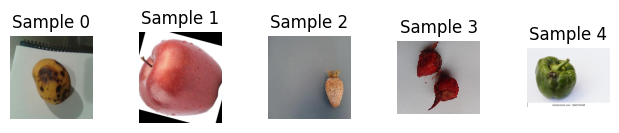

In [2]:
# Initialize the dataset and assign labels based on folder structure
produce_dataset = ProduceDataset(root_dir=PRODUCE_DATESET_PATH, transform=auto_transforms)
produce_dataset.print_class_balance()
produce_dataset.display_examples(num_samples=5, show_transformed=False)


# Transfer Learning vs. Finetuning
Both methods implement a classifer head (the final layer) for the new task (Healthy vs. Rotten). They adapt pre-trained model behaviour in distinct ways:
| Method | Description | When to use? |
|---|---|---|
| Transfer learning | Freeze most or all pre-trained weights and train new classifer head. | Small dataset, similar domain and task. |
| Fine-tuning | Update some or all model weights as well as new classifier head.| Large dataset, less similar domain and task |


In [3]:
# https://medium.com/@marklpd/transfer-learning-finetuning-for-cnns-in-pytorch-5c4ade873d93
# Freeze weights of all layers 
if TRANSFER_TYPE == "FREEZE":
    for parameters in PRETRAINED_MODEL.parameters():
        parameters.requires_grad = False # Do not compute backbone gradients (i.e., freeze weights)

# Modify final classificaiton head from 1000 (Imagenet) => 2 Classes (Healthy vs Rotten)
# Gradients are enabled by default for new layers.
num_features = PRETRAINED_MODEL.classifier[1].in_features
PRETRAINED_MODEL.classifier[1] = nn.Linear(num_features, NUM_CLASSES)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PRETRAINED_MODEL.to(device)
# print(model)

In [4]:
# DEFINE LOSS FUNCTION, OPTIMIZER AND LEARNING RATE SCHEDULER
# Multi-class loss function
criterion = nn.CrossEntropyLoss()

# Stochastic Gradient Descent optimizer - Pass new classifer parameters only (if freezing base model)
# TODO - Verify this functionality
if TRANSFER_TYPE == "FREEZE":
    optimizer = optim.SGD(PRETRAINED_MODEL.classifier.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
else:
    optimizer = optim.SGD(PRETRAINED_MODEL.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

# Learning rate scheduler 
# Decay LR by a factor of 0.1 every 5 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [5]:
# SPLIT DATASET INTO TRAIN AND VALIDATION
# Seed for reproduciability
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# Split dataset
# Stratify to respect the original class distribution between train and eval
train_idx, val_idx = train_test_split(
    range(len(produce_dataset)),
    test_size=1-TEST_SPLIT,
    stratify=produce_dataset.labels,
    random_state=42
)

train_dataset = torch.utils.data.Subset(produce_dataset, train_idx)
val_dataset = torch.utils.data.Subset(produce_dataset, val_idx)

# INTIALIZE DATALOADERS - https://www.geeksforgeeks.org/deep-learning/pytorch-dataloader/
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS) # Shuffle training data for better generalization
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS) # No need to shuffle validation data 

print(f"Training size: {len(train_dataset)} images\nValidation size: {len(val_dataset)} images.")

Training size: 23432 images
Validation size: 5859 images.


In [6]:
# TRAIN/VALIDATION LOOP
# https://medium.com/@ebimsv/mastering-cnns-in-pytorch-week-2-building-and-training-custom-and-pretrained-cnns-for-image-f040572c73c1
class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0
        self.count = 0

    def update(self, value, n=1):
        self.sum += value * n
        self.count += n

    @property
    def avg(self):
        return self.sum / self.count if self.count > 0 else 0

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch, accuracy_metric):
    model.train()
    loss_meter = AverageMeter()
    accuracy_metric.reset()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Training]", leave=False)

    for id, (X_batch, y_batch) in enumerate(progress_bar):
        # Move data to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Zero gradients to not accumulate from previous batch
        optimizer.zero_grad()

        # Calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()


        # Update metrics
        loss_meter.update(loss.item(), X_batch.size(0))
        preds = outputs.argmax(dim=1)
        accuracy_metric.update(preds, y_batch)

        if id % 50 == 0:
            progress_bar.set_postfix(loss=loss_meter.avg, accuracy=accuracy_metric.compute().item())

    avg_loss = loss_meter.avg
    avg_accuracy = accuracy_metric.compute().item()

    return avg_loss, avg_accuracy

def validate(model, dataloader, criterion, device, epoch, accuracy_metric):
    model.eval()
    loss_meter = AverageMeter()
    accuracy_metric.reset()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Validation]", leave=False)
    
    # Disable gradient descent for validation
    with torch.no_grad():
        for id, (X_batch, y_batch) in enumerate(progress_bar):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Update loss and accuracy
            loss_meter.update(loss.item(), X_batch.size(0))
            preds = outputs.argmax(dim=1)
            accuracy_metric.update(preds, y_batch)

            if id % 50 == 0:
                    progress_bar.set_postfix(loss=loss_meter.avg, accuracy=accuracy_metric.compute().item())
        
    avg_loss = loss_meter.avg
    avg_accuracy = accuracy_metric.compute().item()
    
    return avg_loss, avg_accuracy

writer = SummaryWriter()

# Set accuracy metrics
train_accuracy = torchmetrics.Accuracy(task="binary", num_classes=NUM_CLASSES).to(device)
val_accuracy = torchmetrics.Accuracy(task="binary", num_classes=NUM_CLASSES).to(device)

name = pretrained_weights.__class__.__name__
base_name = name.replace("_Weights" , '')
timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
model_save_name = f"{base_name}_{timestamp}"


patience_counter = 0

best_val_loss = float('inf')
best_val_loss = 0.0
for epoch in range(MAXIMUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(PRETRAINED_MODEL, train_loader, criterion, optimizer, device, epoch, train_accuracy)
    val_loss, val_los = validate(PRETRAINED_MODEL, val_loader, criterion, device, epoch, val_accuracy)

    # Step scheduler at each epoch
    lr_scheduler.step()
    
    best_val_loss = float('inf')
    patience_counter = 0

    # Early stopping on val loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(PRETRAINED_MODEL.state_dict(), f'models/task_2/{model_save_name}.pth')
        print(f"New best model saved with Val Loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Log metrics to TensorBoard  
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('Accuracy/Validation', val_los, epoch)

    # Save best model
    if val_los < best_val_loss:
        best_val_loss = val_los
        print(f"New best model saved with Val Acc: {best_val_loss:.4f}")
        torch.save(PRETRAINED_MODEL.state_dict(), f'models/task_2/{model_save_name}.pth')
writer.close()

KeyboardInterrupt: 